<a href="https://colab.research.google.com/github/Gautamvermgv2003/Appnacollege-Demo/blob/main/Solar_Power_Generation_Prediction_Using_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('Plant_1_Generation_Data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Plant_1_Generation_Data.csv'

In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Plant_1_Generation_Data.csv to Plant_1_Generation_Data.csv


In [ ]:
df = pd.read_csv('Plant_1_Generation_Data.csv')
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
0


In [ ]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True, errors='coerce')

In [ ]:
df['DATE_TIME'].isnull().sum()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    43628 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [ ]:
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

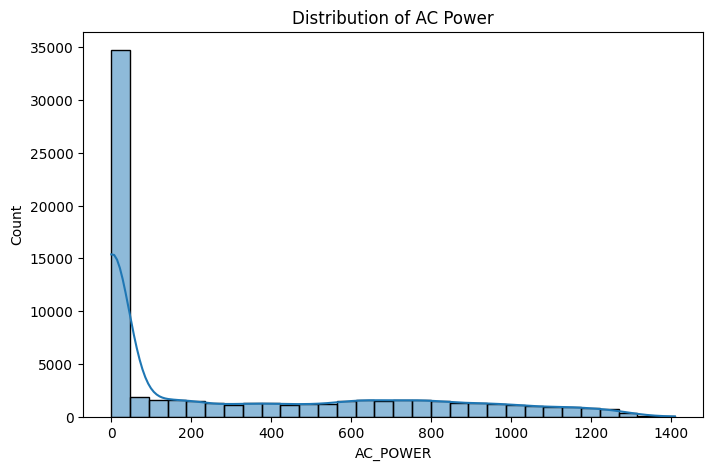

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['AC_POWER'], bins=30, kde=True)
plt.title('Distribution of AC Power')
plt.show()

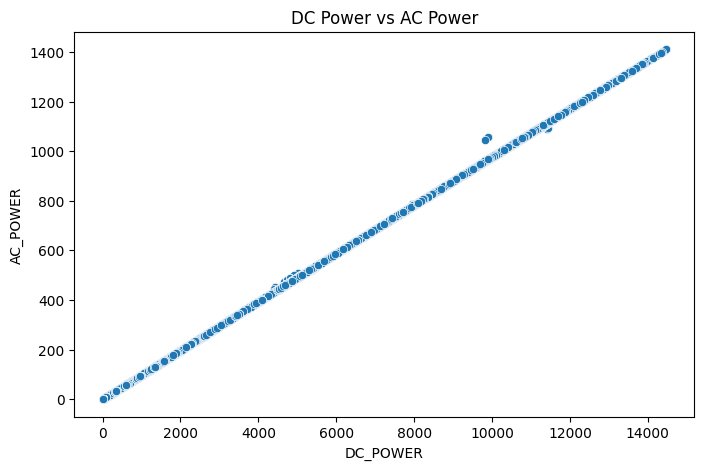

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='DC_POWER', y='AC_POWER', data=df)
plt.title('DC Power vs AC Power')
plt.show()

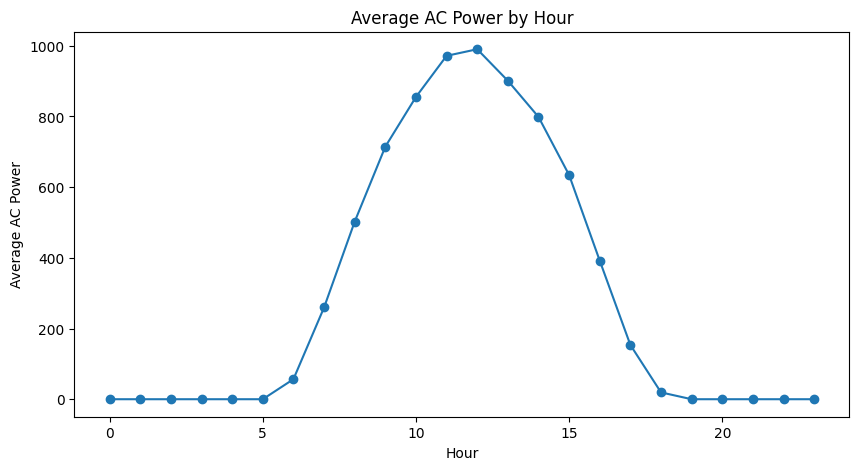

In [ ]:
hourly_power = df.groupby('hour')['AC_POWER'].mean()

plt.figure(figsize=(10,5))
hourly_power.plot(kind='line', marker='o')
plt.title('Average AC Power by Hour')
plt.xlabel('Hour')
plt.ylabel('Average AC Power')
plt.show()

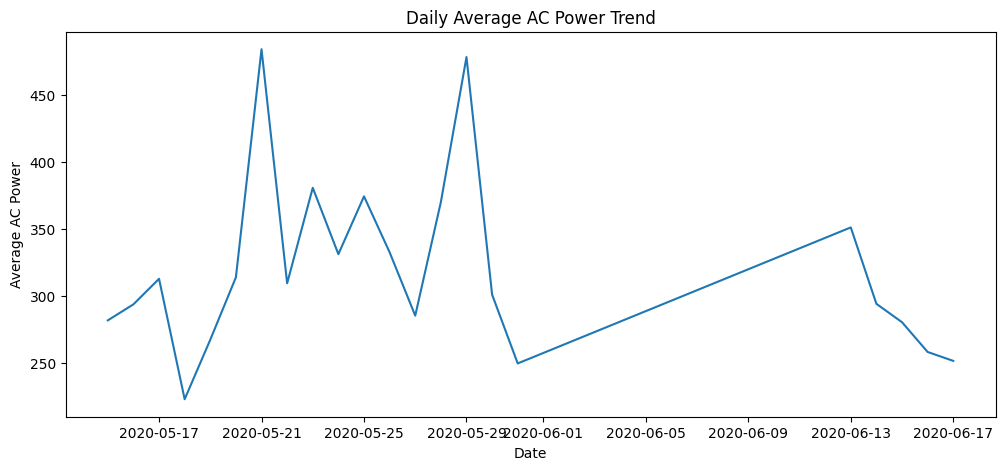

In [ ]:
daily_power = df.groupby(df['DATE_TIME'].dt.date)['AC_POWER'].mean()

plt.figure(figsize=(12,5))
daily_power.plot()
plt.title('Daily Average AC Power Trend')
plt.xlabel('Date')
plt.ylabel('Average AC Power')
plt.show()

In [ ]:
y = df['AC_POWER']

In [ ]:
X = df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute']]
y = df['AC_POWER']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
print(df[['DATE_TIME','day','month','hour','minute']].isnull().sum())

DATE_TIME    25150
day          25150
month        25150
hour         25150
minute       25150
dtype: int64


In [ ]:
df = df.dropna(subset=['DATE_TIME'])

In [ ]:
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

In [ ]:
print(df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute', 'AC_POWER']].isnull().sum())

DC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
day            0
month          0
hour           0
minute         0
AC_POWER       0
dtype: int64


In [ ]:
X = df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute']]
y = df['AC_POWER']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.7349846454690253
MSE: 2.6536445682371683
RMSE: 1.6290010952228264
R2 Score: 0.9999832299288453


In [ ]:
results = pd.DataFrame({
    'Actual_AC_POWER': y_test,
    'Predicted_AC_POWER': y_pred
})

results.head()

,Actual_AC_POWER,Predicted_AC_POWER
67799,943.8000,943.337972
62402,0.0000,0.368930
27261,0.0000,0.161856
16177,886.9625,886.036326
66561,0.0000,0.369163


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Convert DATE_TIME
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True, errors='coerce')

# 2) Drop bad date rows
df = df.dropna(subset=['DATE_TIME']).copy()

# 3) Create time features
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

# 4) Define features and target
X = df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute']]
y = df['AC_POWER']

# 5) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 7) Predict
y_pred = model.predict(X_test)

# 8) Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# 9) Results table
results = pd.DataFrame({
    'Actual_AC_POWER': y_test.values,
    'Predicted_AC_POWER': y_pred
})

print("\nFirst 10 Actual vs Predicted values:")
print(results.head(10))

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Load dataset  ---- IMPORTANT: change file name if needed
df = pd.read_csv('Plant_1_Generation_Data.csv')

# 2) Convert DATE_TIME
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True, errors='coerce')

# 3) Drop rows where date conversion failed
df = df.dropna(subset=['DATE_TIME']).copy()

# 4) Create time features
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

# 5) Check missing values
print("Missing values:")
print(df[['DATE_TIME','DC_POWER','DAILY_YIELD','TOTAL_YIELD','AC_POWER','day','month','hour','minute']].isnull().sum())

# 6) Define features and target
X = df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute']]
y = df['AC_POWER']

# 7) Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8) Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 9) Predict
y_pred = model.predict(X_test)

# 10) Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# 11) Results table
results = pd.DataFrame({
    'Actual_AC_POWER': y_test.values,
    'Predicted_AC_POWER': y_pred
})

print("\nFirst 10 Actual vs Predicted values:")
print(results.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'Plant_1_Generation_Data.csv'

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Plant_1_Generation_Data.csv to Plant_1_Generation_Data.csv


In [ ]:
import os
print(os.listdir())

['.config', 'Plant_1_Generation_Data.csv', 'sample_data']


In [ ]:
import pandas as pd
df = pd.read_csv('Plant_1_Generation_Data.csv')
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Load dataset  ---- IMPORTANT: change file name if needed
df = pd.read_csv('Plant_1_Generation_Data.csv')

# 2) Convert DATE_TIME
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True, errors='coerce')

# 3) Drop rows where date conversion failed
df = df.dropna(subset=['DATE_TIME']).copy()

# 4) Create time features
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

# 5) Check missing values
print("Missing values:")
print(df[['DATE_TIME','DC_POWER','DAILY_YIELD','TOTAL_YIELD','AC_POWER','day','month','hour','minute']].isnull().sum())

# 6) Define features and target
X = df[['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'day', 'month', 'hour', 'minute']]
y = df['AC_POWER']

# 7) Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8) Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 9) Predict
y_pred = model.predict(X_test)

# 10) Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# 11) Results table
results = pd.DataFrame({
    'Actual_AC_POWER': y_test.values,
    'Predicted_AC_POWER': y_pred
})

print("\nFirst 10 Actual vs Predicted values:")
print(results.head(10))

Missing values:
DATE_TIME      0
DC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
AC_POWER       0
day            0
month          0
hour           0
minute         0
dtype: int64

Model Performance:
MAE: 0.7349846454690253
MSE: 2.6536445682371683
RMSE: 1.6290010952228264
R2 Score: 0.9999832299288453

First 10 Actual vs Predicted values:
   Actual_AC_POWER  Predicted_AC_POWER
0       943.800000          943.337972
1         0.000000            0.368930
2         0.000000            0.161856
3       886.962500          886.036326
4         0.000000            0.369163
5       308.857143          307.413432
6        42.225000           42.982249
7       409.957143          408.022326
8         0.000000            0.353418
9       145.228571          145.717254


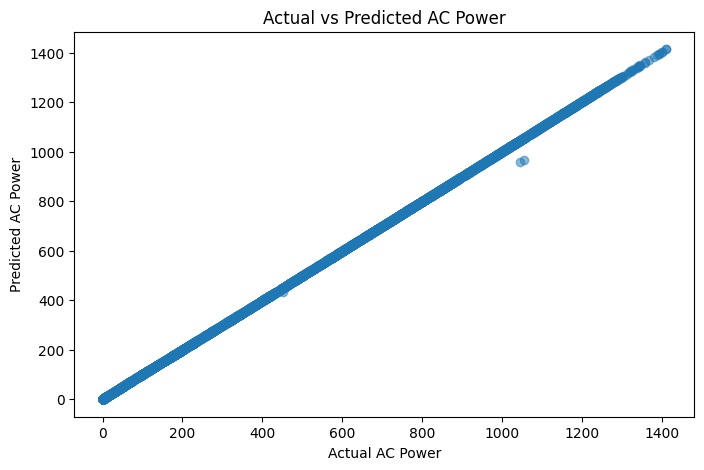

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

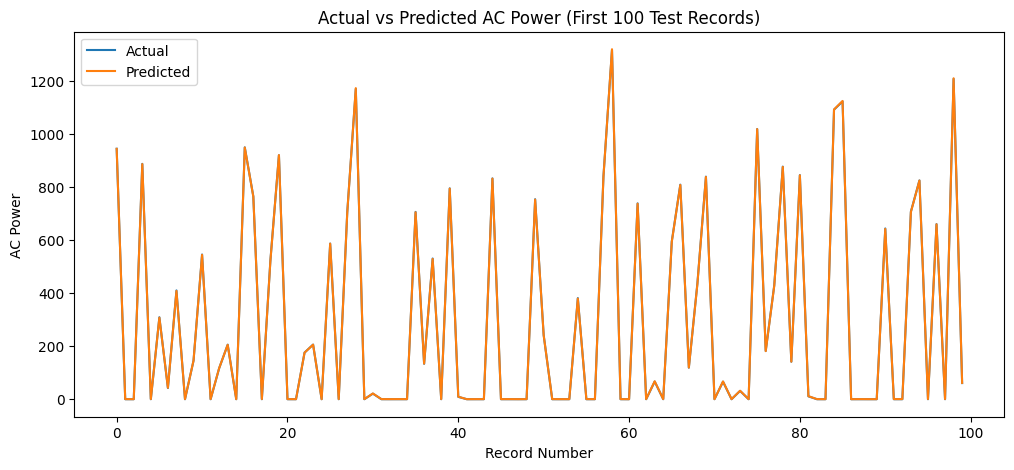

In [ ]:
results_sample = results.head(100).reset_index(drop=True)

plt.figure(figsize=(12,5))
plt.plot(results_sample['Actual_AC_POWER'], label='Actual')
plt.plot(results_sample['Predicted_AC_POWER'], label='Predicted')
plt.title('Actual vs Predicted AC Power (First 100 Test Records)')
plt.xlabel('Record Number')
plt.ylabel('AC Power')
plt.legend()
plt.show()

In [ ]:
results = pd.DataFrame({
    'Actual_AC_POWER': y_test,
    'Predicted_AC_POWER': y_pred
})

results.head()

,Actual_AC_POWER,Predicted_AC_POWER
67799,943.8000,943.337972
62402,0.0000,0.368930
27261,0.0000,0.161856
16177,886.9625,886.036326
66561,0.0000,0.369163


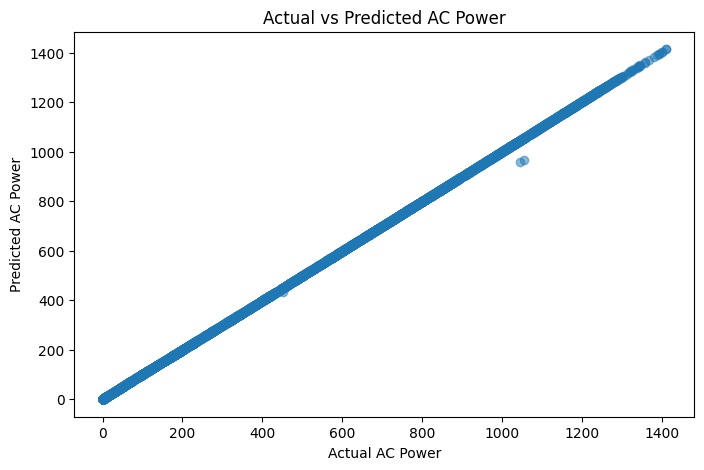

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

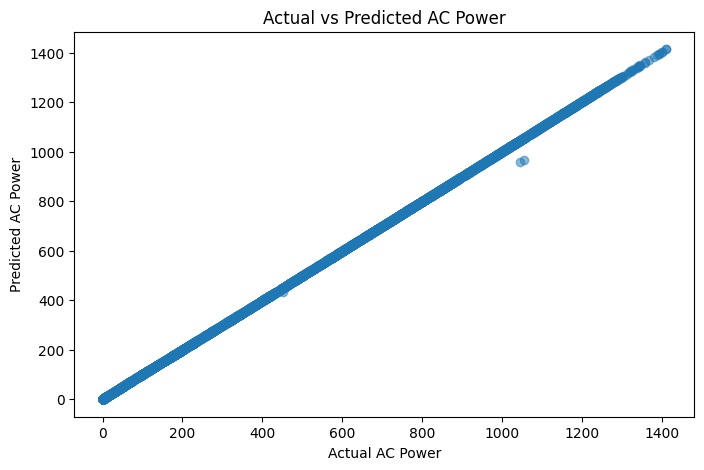

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

In [ ]:
results.to_csv("Solar_Power_Prediction_Output.csv", index=False)

In [ ]:
from google.colab import files
files.download('Solar_Power_Prediction_Output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# 1) Start from your cleaned dataframe df
# Make sure DATE_TIME is already converted and time columns are created

# 2) Create a copy of the full dataframe
final_df = df.copy()

# 3) Add empty prediction columns first
final_df['Predicted_AC_POWER'] = np.nan
final_df['Actual_AC_POWER'] = np.nan

# 4) Put actual and predicted values back only on test rows using X_test index
final_df.loc[X_test.index, 'Actual_AC_POWER'] = y_test
final_df.loc[X_test.index, 'Predicted_AC_POWER'] = y_pred

# 5) Create error columns
final_df['Error'] = final_df['Actual_AC_POWER'] - final_df['Predicted_AC_POWER']
final_df['Absolute_Error'] = final_df['Error'].abs()

# 6) Save final file for Power BI
final_df.to_csv('Solar_Power_Final_PowerBI.csv', index=False)

print("Final merged Power BI file created successfully!")
print(final_df.head())

Final merged Power BI file created successfully!
   DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  day  month  hour  minute  Predicted_AC_POWER  Actual_AC_POWER  \
0    6259559.0   15      5     0       0            0.341640              0.0   
1    6183645.0   15      5     0       0            0.343369              0.0   
2    6987759.0   15      5     0       0                 NaN              NaN   
3    7602960.0   15      5     0       0                 NaN              NaN   
4    7158964.0   15      5     0       0            0.321145              0.0   

      E

In [ ]:
from google.colab import files
files.download('Solar_Power_Final_PowerBI.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>